# Cell atlas overview: joint mC + 3C clustering (Fig 1A,C,D,E)

Part of the **[Fig. 1 chapter](fig1.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


## 📥 Required input files

This notebook reads the following files (paths resolve from `ENTEX_ROOT`/`REF_ROOT`; the setup cell sets them). See the chapter's `inputs.md` for RAW-vs-derived tags.

- `f'{indir}L1color.tsv'`  ·  _metadata: color_
- `f'{indir}tissuecolor.tsv'`  ·  _metadata: color_
- `f'{REF_ROOT}/hg38/gencode/v30/gencode.v30.annotation.gene.flat.tsv.gz'`  ·  _ref: gencode_
- `f'{cooldir}{ct}/{ct}.Q.cool'`  ·  _contacts (cool)_
- `f'{indir}clustering/merged/5kCG100k3C_summary.h5ad'`  ·  _joint summary obj_
- `f'{indir}clustering/merged/L1/5kCG100k3C_embed.h5ad'`  ·  _embedding h5ad_
- `f'{indir}clustering/merged/L1/5kCG_lsi.h5ad'`  ·  _raw embedding_
- `f'{indir}clustering/merged/L1/100k3C_pca.h5ad'`  ·  _raw embedding_
- `f'{outdir}5kCG100k3C_summary.tsv.gz'`  ·  _joint summary obj_
- `f'{outdir}L2/{ctname}/5kCG100k3C_embed.h5ad'`  ·  _embedding h5ad_
- `f'{outdir}L2/{ctname}/5kCG_embed.h5ad'`  ·  _embedding h5ad_
- `f'{outdir}L2/{ctname}/100k3C_embed.h5ad'`  ·  _embedding h5ad_
- `f'{indir}clustering/tissue/L1/{t}/5kCG100k3C_embed.h5ad'`  ·  _embedding h5ad_
- `f'{indir}clustering/tissue/L1/{t}/mCG_5kb_lsi.h5ad'`  ·  _raw embedding_
- `f'{indir}clustering/tissue/L1/{t}/HiC_100kb_pca.h5ad'`  ·  _raw embedding_
- `f'{outdir}5kCG100k3C_summary.csv.gz'`  ·  _joint summary obj_
- `f'{indir}subtype_meta.tsv'`  ·  _metadata_


In [ ]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

In [ ]:
from glob import glob

import anndata
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce
import seaborn as sns
from ALLCools.clustering import *
from ALLCools.integration.seurat_class import SeuratIntegration
from ALLCools.plot import *
from sklearn.metrics import pairwise_distances, roc_auc_score
from sklearn.preprocessing import normalize

import warnings
warnings.filterwarnings("ignore")

mpl.style.use("default")
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = "Helvetica"


In [ ]:
indir = f'{ENTEX_ROOT}/'
outdir = f'{indir}clustering/merged/'


In [ ]:
L1_meta = pd.read_csv(f'{indir}L1color.tsv', sep='\t', header=0, index_col=0)
L1_meta = L1_meta.drop(['c35','c36'], axis=0)
L1_color = L1_meta['color'].to_dict()
L1_annot = L1_meta['L1_abbr'].to_dict()
L1_color.update({L1_annot[k]: L1_color[k] for k in L1_annot if k in L1_color})  # also key by name
tissue_meta = pd.read_csv(f'{indir}tissuecolor.tsv', sep='\t', header=0, index_col=0)
tissue_color = tissue_meta['color'].to_dict()
tissue_annot = tissue_meta['tissue_annot'].to_dict()
tissue_color.update({tissue_annot[k]: tissue_color[k] for k in tissue_annot})  # also key by annot name


## Example in Fig1

In [ ]:
leg = pd.Index(['c0', 'c1'])
cooldir = f'{indir}loop/majortype/'


In [ ]:
gene_meta = pd.read_csv(f'{REF_ROOT}/hg38/gencode/v30/gencode.v30.annotation.gene.flat.tsv.gz', sep='\t', header=0)
gene_meta['gene_id_idx'] = gene_meta['gene_id'].str.split('.').str[0]


In [ ]:
gtmp = 'CD3D'
lslop, rslop = 1500000, 1500000

chrom, start, end, strand = gene_meta.loc[gene_meta['gene_name']==gtmp, ['chrom', 'start', 'end', 'strand']].iloc[0]
if strand=='+':
    tss = start
else:
    tss = end

ll, rr = (tss - lslop), (tss + rslop)
print(chrom, ll, rr)


In [ ]:
resl = 10000
loopl, loopr = (ll//resl), (rr//resl)
print(loopl, loopr)

In [ ]:
## Load cell type Q
import cooler
from scipy import ndimage as nd

dstall = []
for ct in leg:
    cool = cooler.Cooler(f'{cooldir}{ct}/{ct}.Q.cool')
    Q = cool.matrix(balance=False, sparse=True).fetch(chrom).tocsr()
    tmp = Q[loopl:loopr, loopl:loopr].toarray()
    tmp = nd.rotate(tmp, 45, order=0, reshape=True, prefilter=False, cval=0)
    dstall.append(tmp)
    print(ct)
    

In [ ]:
import pysam
from scipy.sparse import csr_matrix


In [ ]:
def load_allc(ct, chrom, start, end):
    global indir
    allc_path = f'{indir}merged_allc/L1/CGN/{ct}.CGN-Merge.allc.tsv.gz'
    # allc_path = f'{indir}merged_allc/L1/CHN/{ct}.allc.tsv.gz'
    idx, data_mc, data_cov = [], [], []
    with pysam.TabixFile(allc_path) as allc:
        allc_lines = allc.fetch(chrom, start+1, end)
        for line in allc_lines:
            _, pos, _, context, mc, cov, *_ = line.split("\t")
            # if context[1] in 'GN':
            #     continue
            pos, mc, cov = int(pos), int(mc), int(cov)
            idx.append(pos-start-1)
            data_mc.append(mc)
            data_cov.append(cov)
    return  np.array([idx, data_mc, data_cov])

start = loopl * resl
end = loopr * resl
data_mc_row, data_mc_col, data_mc_data = [], [], []
data_cov_row, data_cov_col, data_cov_data = [], [], []
for i,ct in enumerate(leg):
    idx, tmp_mc, tmp_cov = load_allc(ct, chrom, start, end)
    posfilter = np.ones(len(idx)).astype(bool)
    # for bed in rm_list:
    #     for xx,yy in bed[chrom]:
    #         posfilter[np.logical_and(idx>=xx, idx<=yy)] = False
    # print(np.sum(posfilter)/len(posfilter))
    # idx = idx[posfilter]
    # tmp_mc = tmp_mc[posfilter]
    # tmp_cov = tmp_cov[posfilter]
    data_mc_row.extend(np.zeros(len(idx))+i)
    data_mc_col.extend(idx)
    data_mc_data.extend(tmp_mc)
    data_cov_row.extend(np.zeros(len(idx))+i)
    data_cov_col.extend(idx)
    data_cov_data.extend(tmp_cov)
    print(ct)

data_mc_cg = csr_matrix((data_mc_data, (data_mc_row, data_mc_col)), shape=[len(leg), end-start])
data_cov_cg = csr_matrix((data_cov_data, (data_cov_row, data_cov_col)), shape=[len(leg), end-start])


In [ ]:
def load_allc(ct, chrom, start, end):
    global indir
    # allc_path = f'{indir}merged_allc/L1/CGN/{ct}.CGN-Merge.allc.tsv.gz'
    allc_path = f'{indir}merged_allc/L1/CHN/{ct}.allc.tsv.gz'
    idx, data_mc, data_cov = [], [], []
    with pysam.TabixFile(allc_path) as allc:
        allc_lines = allc.fetch(chrom, start+1, end)
        for line in allc_lines:
            _, pos, _, context, mc, cov, *_ = line.split("\t")
            if context[1] in 'GN':
                continue
            pos, mc, cov = int(pos), int(mc), int(cov)
            idx.append(pos-start-1)
            data_mc.append(mc)
            data_cov.append(cov)
    return  np.array([idx, data_mc, data_cov])

start = loopl * resl
end = loopr * resl
data_mc_row, data_mc_col, data_mc_data = [], [], []
data_cov_row, data_cov_col, data_cov_data = [], [], []
for i,ct in enumerate(leg):
    idx, tmp_mc, tmp_cov = load_allc(ct, chrom, start, end)
    posfilter = np.ones(len(idx)).astype(bool)
    # for bed in rm_list:
    #     for xx,yy in bed[chrom]:
    #         posfilter[np.logical_and(idx>=xx, idx<=yy)] = False
    # print(np.sum(posfilter)/len(posfilter))
    # idx = idx[posfilter]
    # tmp_mc = tmp_mc[posfilter]
    # tmp_cov = tmp_cov[posfilter]
    data_mc_row.extend(np.zeros(len(idx))+i)
    data_mc_col.extend(idx)
    data_mc_data.extend(tmp_mc)
    data_cov_row.extend(np.zeros(len(idx))+i)
    data_cov_col.extend(idx)
    data_cov_data.extend(tmp_cov)
    print(ct)

data_mc_ch = csr_matrix((data_mc_data, (data_mc_row, data_mc_col)), shape=[len(leg), end-start])
data_cov_ch = csr_matrix((data_cov_data, (data_cov_row, data_cov_col)), shape=[len(leg), end-start])


In [ ]:
colors = {'CG':sns.color_palette('Blues',1), 'CH':sns.color_palette('Purples',1)}

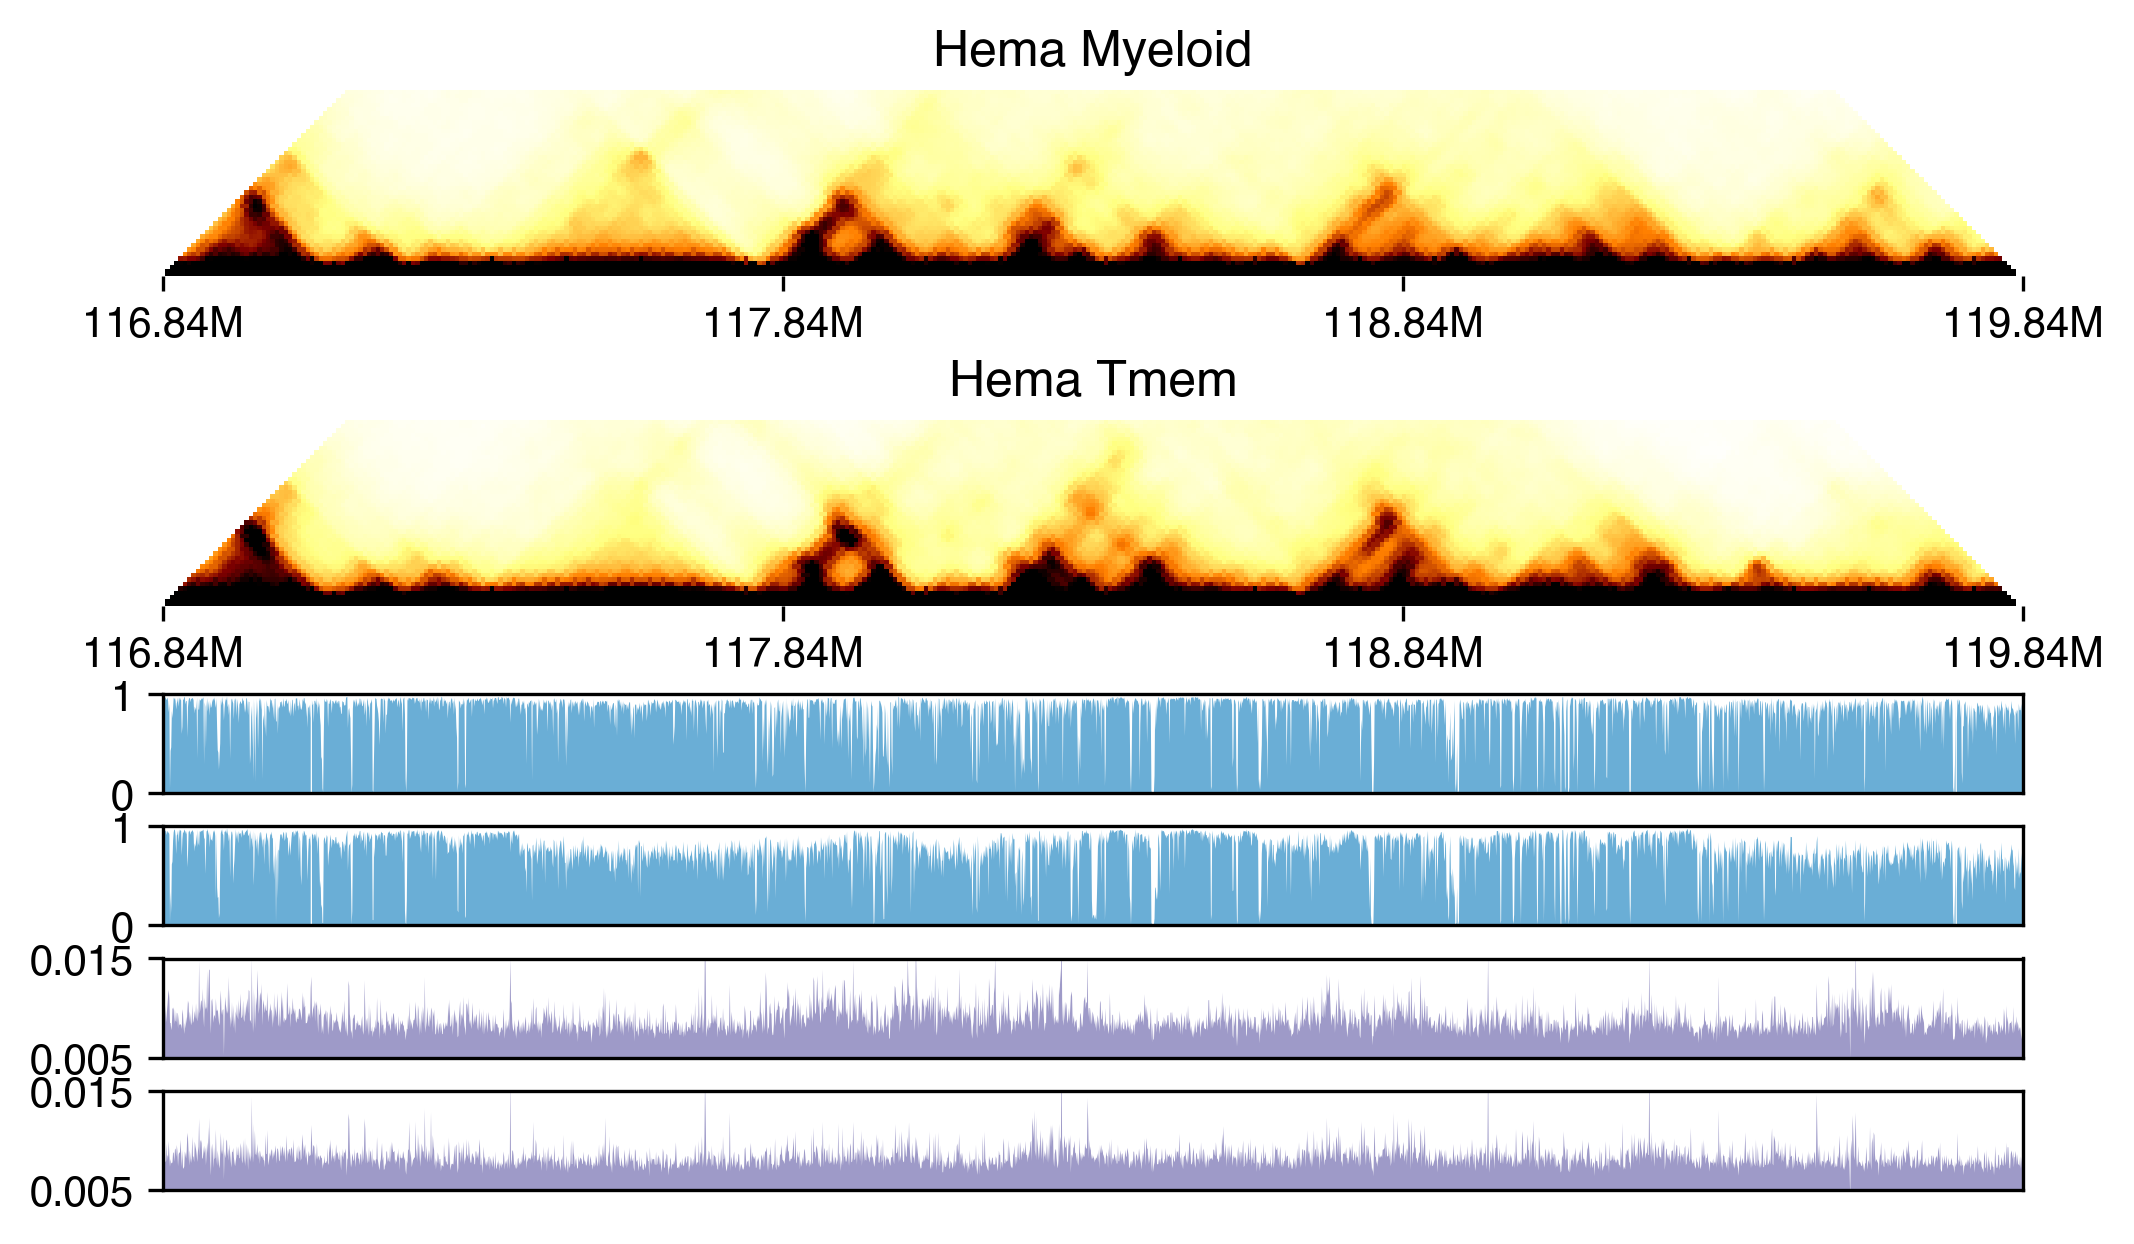

In [ ]:
resm = 1000
fig, axes = plt.subplots(len(leg)*3, 1, figsize=(8, np.sum(np.repeat([3,1,1],len(leg)).tolist())/2), 
                         gridspec_kw={'height_ratios': np.repeat([3,1,1],len(leg)).tolist()}, dpi=300)


for i in range(len(leg)):
    ax = axes[i]
    ax.set_title(leg.map(L1_annot)[i])
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    img = ax.imshow(dstall[i], cmap='afmhot_r', vmin=0, vmax=0.015, 
                    interpolation='none', rasterized=True)
    h = len(dstall[i])
    ax.set_ylim([0.5*h, 0.4*h])
    ax.set_xlim([0, h])
    ax.set_yticks([])
    ax.set_yticklabels([])
    # ax.scatter((tmpl[:, 0]+tmpl[:, 1])/np.sqrt(2), 0.5*h-(tmpl[:, 1]-tmpl[:, 0])/np.sqrt(2), 
    #        alpha=0.1, s=10, marker='D', edgecolors='c', color='none')
    ax.set_xlim([0, (loopr-loopl-1)*np.sqrt(2)])
    ax.set_xticks(np.sqrt(2)*np.array(np.arange(0, loopr-loopl+1, 100).tolist()))
    ax.set_xticklabels([])
    ax.set_xticklabels([f'{(xx+loopl)/100}M' for xx in np.arange(0, loopr-loopl+1, 100)])

    ax = axes[2+i]
    mc_tmp = data_mc_cg[i].toarray()[0]
    cov_tmp = data_cov_cg[i].toarray()[0]
    tmp = mc_tmp.reshape((-1, resm)).sum(axis=1) / cov_tmp.reshape((-1, resm)).sum(axis=1)
    x = np.arange(len(tmp))
    nbins = tmp.shape[0]
    ax.set_xlim([0, nbins])
    ax.set_xticks([])
    ax.set_ylim([0, 1])
    ax.set_yticks([0, 1])
    ax.fill_between(x, tmp, 0, where=tmp >= 0, facecolor=colors['CG'], interpolate=True)
    
    ax = axes[4+i]
    mc_tmp = data_mc_ch[i].toarray()[0]
    cov_tmp = data_cov_ch[i].toarray()[0]
    tmp = mc_tmp.reshape((-1, resm)).sum(axis=1) / cov_tmp.reshape((-1, resm)).sum(axis=1)
    x = np.arange(len(tmp))
    nbins = tmp.shape[0]
    ax.set_xlim([0, nbins])
    ax.set_xticks([])
    ax.set_ylim([0.005, 0.015])
    ax.set_yticks([0.005, 0.015])
    ax.fill_between(x, tmp, 0, where=tmp >= 0, facecolor=colors['CH'], interpolate=True)
    
# fig.tight_layout()
fig.savefig('clustering_summary/browser_example.pdf', transparent=True)


## Plot all cell tSNE

In [ ]:
def dump_embedding(adata, name, n_dim=2):
    # put manifold coordinates into adata.obs
    for i in range(n_dim):
        adata.obs[f'{name}_{i}'] = adata.obsm[f'X_{name}'][:, i]
    return adata


In [ ]:
adata = anndata.read_h5ad(f'{indir}clustering/merged/5kCG100k3C_summary.h5ad')
adata

In [ ]:
selc = np.array([('TrCo_' in xx) and ('_Plate1-' in xx) for xx in adata.obs.index])
adata.obs.loc[selc, 'mCGFrac']


In [ ]:
tmp = anndata.read_h5ad(f'{indir}clustering/merged/L1/5kCG100k3C_embed.h5ad')
tmp = tmp[adata.obs.index].copy()
tmp

In [ ]:
adata.obsm['5kCG100k3C_u50pc50'] = tmp.obsm['5kCG100k3C_u50pc50']
adata.obsm['5kCG100k3C_u50pc50_tsne'] = tmp.obsm['5kCG100k3C_u50pc50_tsne']


In [ ]:
tmp = anndata.read_h5ad(f'{indir}clustering/merged/L1/5kCG_lsi.h5ad')
tmp = tmp[adata.obs.index].copy()
tmp

In [ ]:
adata.obsm['5kCG_u50_seuratL2_tsne'] = tmp.obsm['5kCG_u50_seuratL2_tsne']


In [ ]:
tmp = anndata.read_h5ad(f'{indir}clustering/merged/L1/100k3C_pca.h5ad')
tmp = tmp[adata.obs.index].copy()
tmp

In [ ]:
adata.obsm['100k3C_pc50_seuratL2_tsne'] = tmp.obsm['100k3C_pc50_seuratL2_tsne']


In [ ]:
adata.write_h5ad(f'{indir}clustering/merged/5kCG100k3C_summary.h5ad')


In [ ]:
L1_meta = pd.read_csv(f'{indir}L1color.tsv', sep='\t', header=0, index_col=0)
L1_color = L1_meta['color'].to_dict()
L1_annot = L1_meta['L1_abbr'].to_dict()
L1_color.update({L1_annot[k]: L1_color[k] for k in L1_annot if k in L1_color})  # also key by name
tissue_meta = pd.read_csv(f'{indir}tissuecolor.tsv', sep='\t', header=0, index_col=0)
tissue_color = tissue_meta['color'].to_dict()
tissue_annot = tissue_meta['tissue_annot'].to_dict()
tissue_color.update({tissue_annot[k]: tissue_color[k] for k in tissue_annot})  # also key by annot name


In [ ]:
adata.obs['L1_annot'] = adata.obs['L1'].map(L1_annot)
adata.obs['tissue_annot'] = adata.obs['Tissue'].map(tissue_annot)


In [ ]:
npc_cg, npc_3c = 50, 50

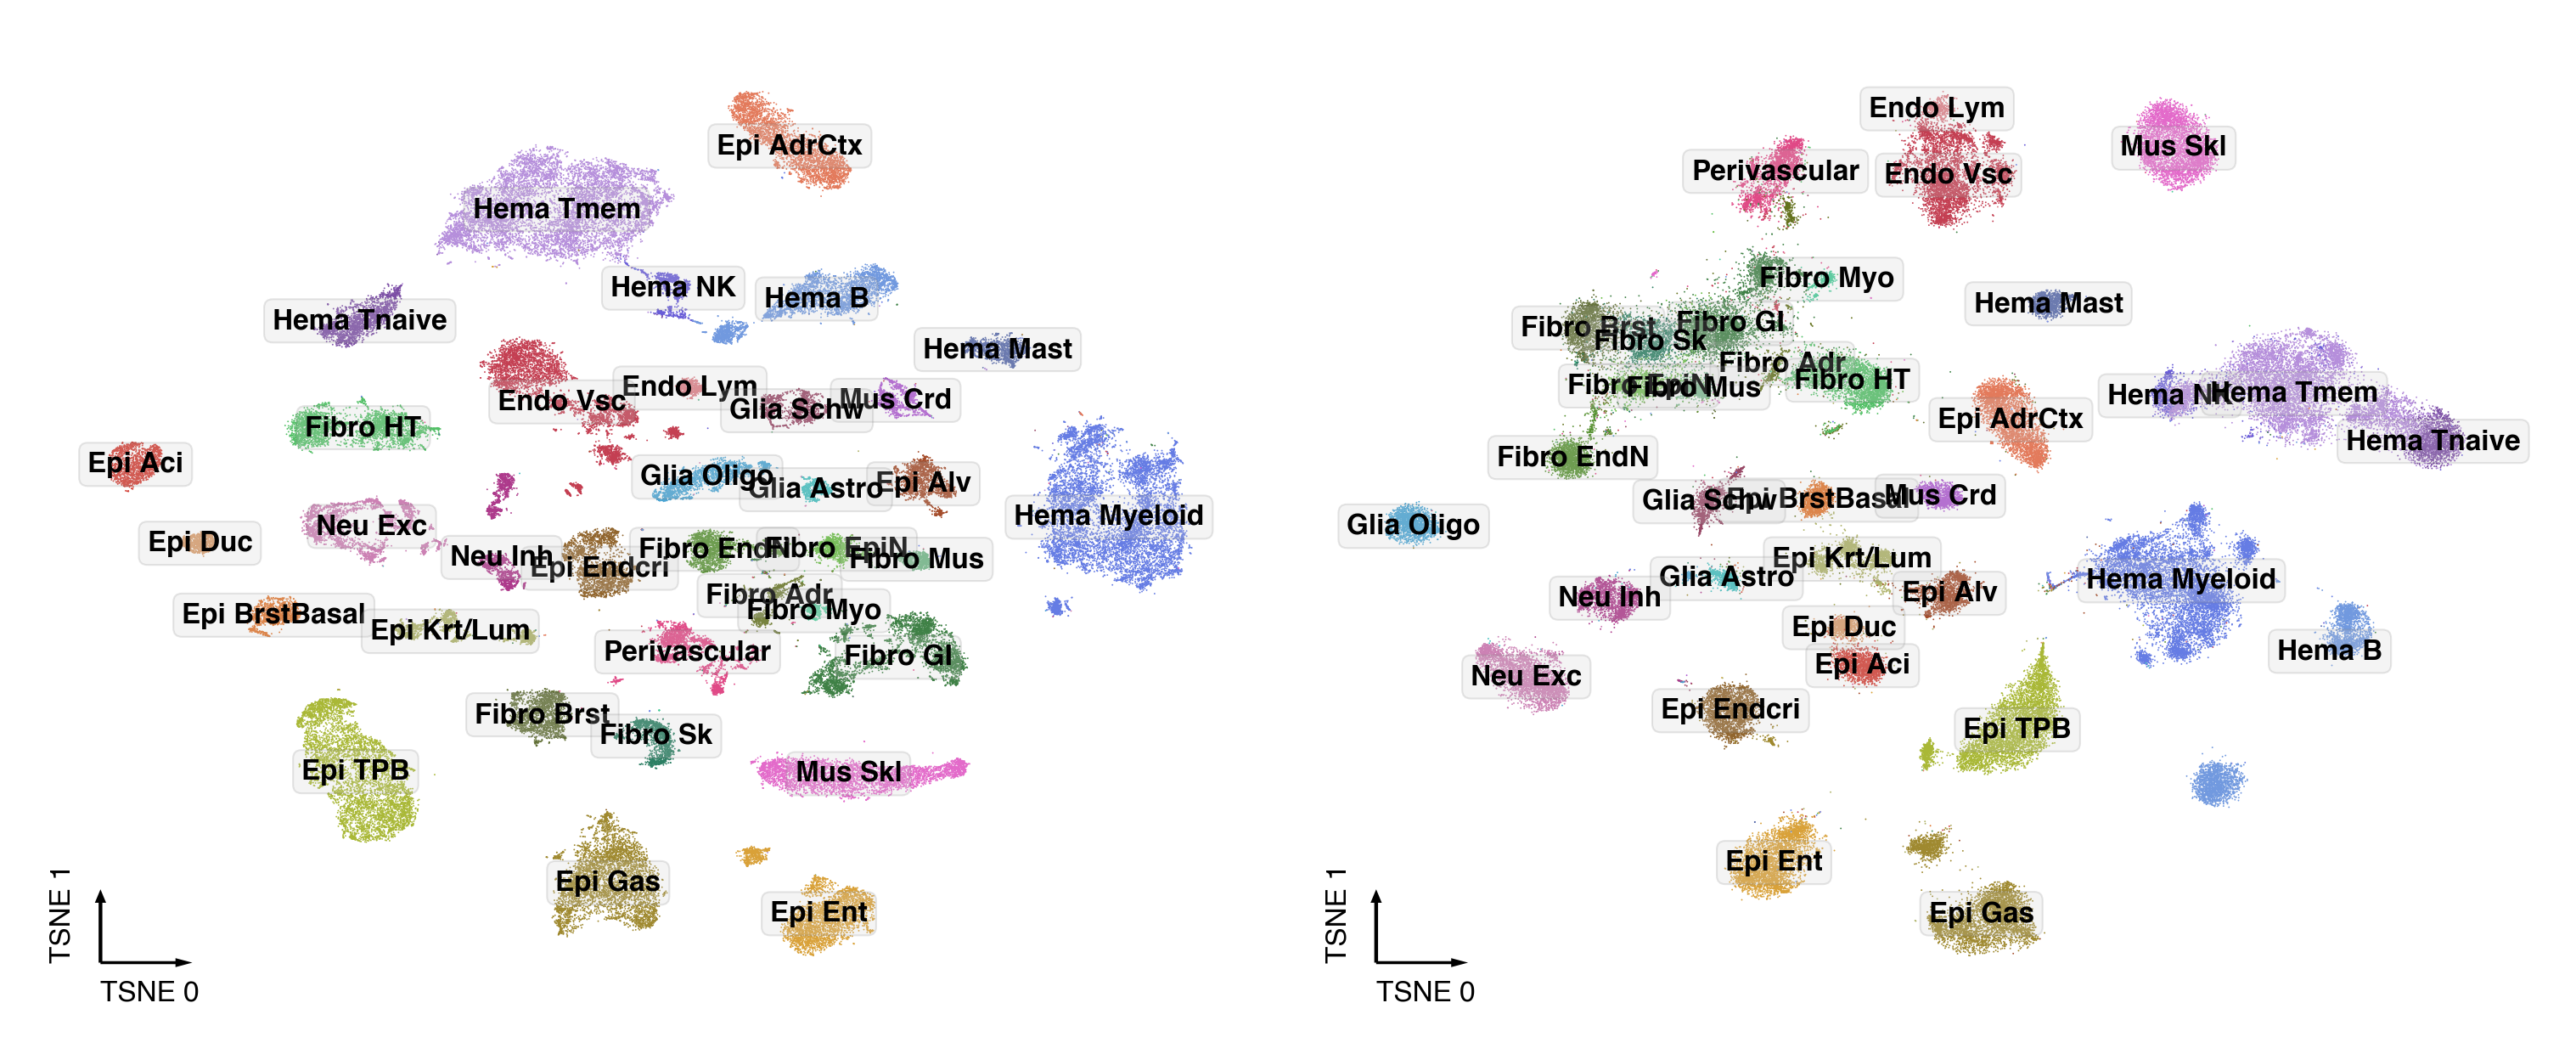

In [ ]:
ds = 0.2
coord_base = 'tsne'

fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=300, constrained_layout=True)

for xx,ax in zip([f'5kCG_u{npc_cg}', f'100k3C_pc{npc_3c}'], axes):
    adata.obsm[f'X_{coord_base}'] = adata.obsm[f'{xx}_seuratL2_{coord_base}'].copy()
    dump_embedding(adata, coord_base)
    tmp = adata.obs.copy()
    
    # ax = axes[0, 1]
    # _ = categorical_scatter(data=tmp,
    #                         ax=ax,
    #                         coord_base=coord_base,
    #                         hue='tissue_annot',
    #                         s=ds,
    #                         labelsize=8,
    #                         max_points=None,
    #                         palette=tissue_color,
    #                         scatter_kws={'rasterized':True},
    #                         # show_legend=True
    #                        )

    _ = categorical_scatter(data=tmp,
                            ax=ax,
                            coord_base=coord_base,
                            hue='L1',
                            text_anno='L1_annot', 
                            s=ds,
                            labelsize=8,
                            max_points=None,
                            palette=L1_color,
                            scatter_kws={'rasterized':True},
                            # legend_kws={'ncol':1}, 
                            # show_legend=True
                           )

plt.savefig('clustering_summary/All_modality_cluster.pdf', transparent=True)


In [ ]:
leg = ['Epi AdrCtx', 'Epi Alv', 'Epi BrstBasal', 'Epi Krt/Lum', 
       'Epi Aci', 'Epi Duc', 'Epi Endcri', 'Epi Ent', 'Epi Gas', 'Epi TPB',
       'Mus Crd', 'Mus Skl', 
       'Glia Astro', 'Glia Oligo', 'Neu Exc', 'Neu Inh', 'Glia Schw', 
       'Fibro Adr', 'Fibro Brst', 'Fibro EndN', 'Fibro EpiN', 'Fibro GI', 
       'Fibro HT', 'Fibro Mus', 'Fibro Myo', 'Fibro Sk',
       'Hema Mast', 'Hema Myeloid', 'Hema B', 'Hema NK', 'Hema Tmem', 'Hema Tnaive', 
       'Endo Lym', 'Endo Vsc', 'Perivascular']


In [ ]:
count = adata.obs[['Tissue', 'L1_annot']].value_counts().unstack().fillna(0)[leg]
count = count / count.sum(axis=0)

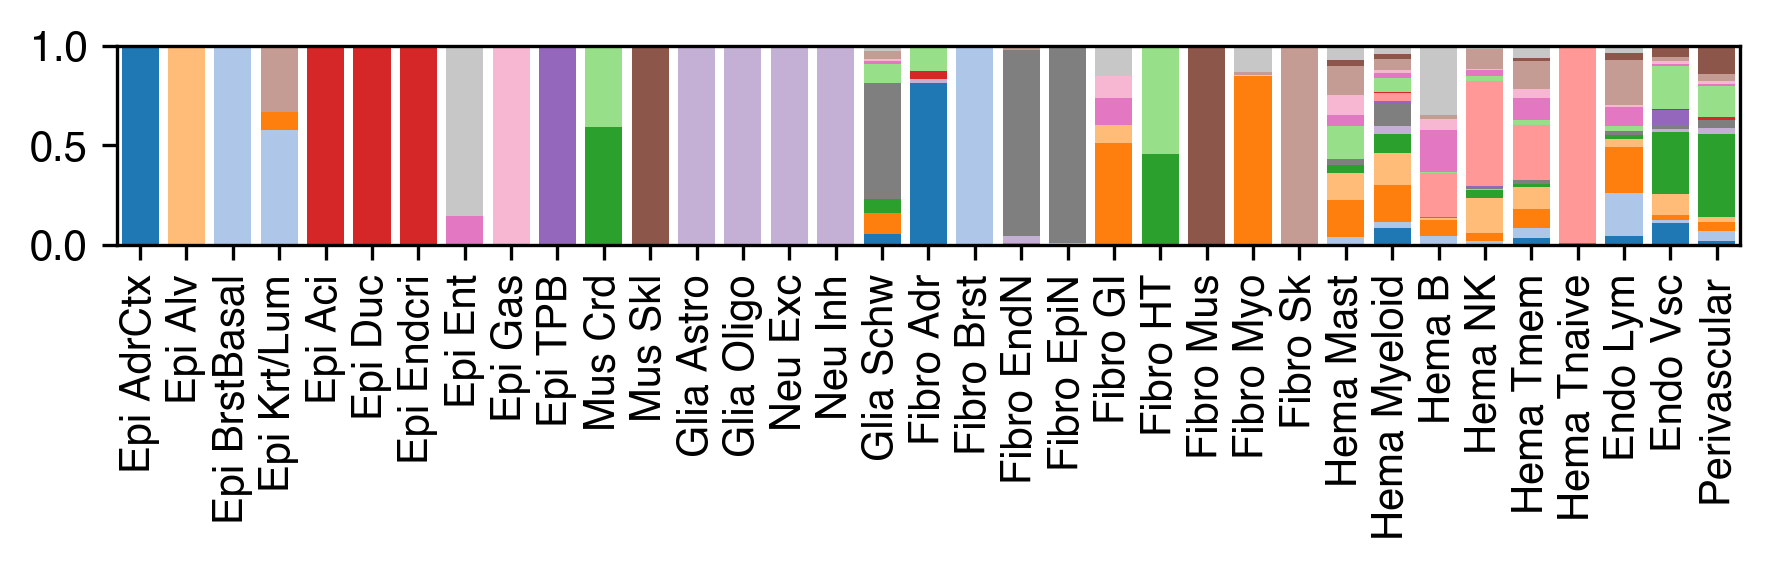

In [ ]:
fig, ax = plt.subplots(figsize=(6,2), dpi=300)
idx = np.arange(count.shape[1])
bottom = np.zeros(count.shape[1])
for xx in count.index:
    tmp = count.loc[xx]
    ax.bar(idx, tmp, width=0.8, bottom=bottom, color=tissue_color[xx])
    bottom += tmp
    
ax.set_xticks(idx)
ax.set_xticklabels(count.columns, rotation=90)
ax.set_xlim([-0.5, count.shape[1]-0.5])
plt.tight_layout()
fig.savefig('clustering_summary/L1_tissueratio.pdf', transparent=True)


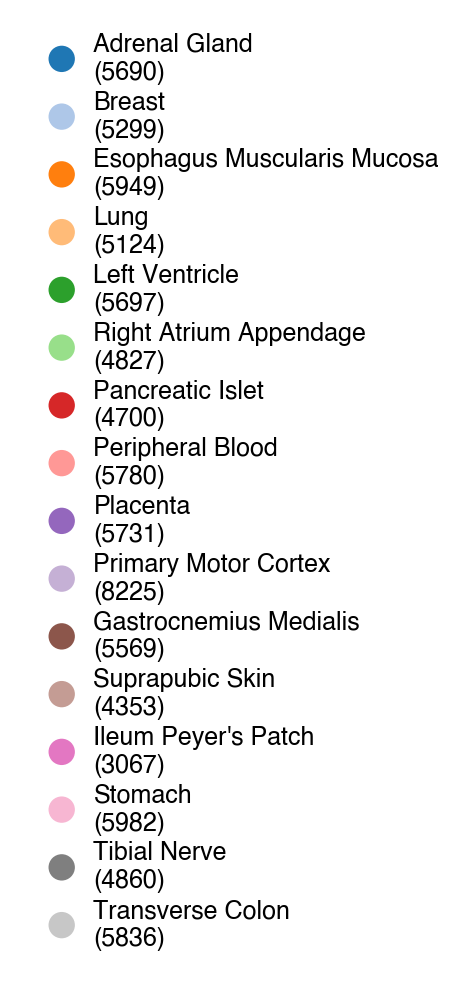

In [ ]:
count = adata.obs['Tissue'].value_counts().loc[tissue_meta.index]

fig, ax = plt.subplots(figsize=(1.5, 4), dpi=300)
for i,xx in enumerate(count.index):
    ax.scatter(0, i, c=tissue_color[xx], s=40, edgecolor='none')
    ax.text(0.5, i, f'{tissue_annot[xx]}\n({count.loc[xx]})', ha='left', va='center', fontsize=6)

ax.set_xlim([-0.5, 5])
ax.set_ylim([15.5, -0.5])
ax.axis('off')
fig.savefig('clustering_summary/tissue_legend.pdf', transparent=True)


## Merge metadata and different level coordinates